### Импорт библиотек

In [59]:
import requests
import xml.etree.ElementTree as ET
import time
import re
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Set

### Конфигурация

In [60]:
SUBJECTS = {
    'math.CO': 'Combinatorics',
    'math.ST': 'Statistics Theory',
    'math.LO': 'Logic',
    'math.OA': 'Operator Algebras',
    'math.PR': 'Probability'
}

### Загрузка данных

In [61]:
def fetch_arxiv_papers(subjects, max_results=60):
    base_url = "http://export.arxiv.org/api/query?"
    papers = []

    for category in subjects:
        query = f"search_query=cat:{category}&max_results={max_results}&sortBy=submittedDate&sortOrder=descending"
        url = base_url + query

        try:
            response = requests.get(url)
            response.raise_for_status()
            root = ET.fromstring(response.content)
            namespace = '{http://www.w3.org/2005/Atom}'

            for entry in root.findall(f'.//{namespace}entry'):
                paper = {
                    'id': entry.find(f'{namespace}id').text if entry.find(f'{namespace}id') is not None else '',
                    'title': entry.find(f'{namespace}title').text.strip() if entry.find(
                        f'{namespace}title') is not None else '',
                    'summary': entry.find(f'{namespace}summary').text.strip() if entry.find(
                        f'{namespace}summary') is not None else '',
                    'authors': [author.find(f'{namespace}name').text for author in entry.findall(f'{namespace}author')],
                    'categories': [cat.attrib.get('term', '') for cat in entry.findall(f'{namespace}category')],
                }
                papers.append(paper)

            print(f"Загружено из {category}: {len([p for p in papers if category in p['categories']])} статей")
            time.sleep(1)

        except Exception as e:
            print(f"Ошибка {category}: {e}")
    
    return papers


papers = fetch_arxiv_papers(SUBJECTS.keys())
print(f"Всего статей: {len(papers)}")

Загружено из math.CO: 60 статей
Загружено из math.ST: 60 статей
Загружено из math.LO: 61 статей
Загружено из math.OA: 62 статей
Загружено из math.PR: 74 статей
Всего статей: 300


### Извлечение ключевых слов

In [62]:
def extract_keywords(text, max_words=8):
    if not text:
        return []

    text = re.sub(r'[^\w\s]', ' ', text.lower())
    words = text.split()

    stop_words = {'the', 'and', 'of', 'in', 'to', 'a', 'an', 'for', 'on', 'with',
                  'by', 'as', 'at', 'from', 'that', 'this', 'is', 'are', 'was', 'were'}

    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    word_counts = Counter(filtered_words)

    return [word for word, count in word_counts.most_common(max_words)]


for paper in papers:
    combined_text = paper['title'] + ' ' + paper['summary']
    paper['keywords'] = extract_keywords(combined_text)

print("Ключевые слова извлечены для всех статей")

Ключевые слова извлечены для всех статей


### Построение графа ключевых слов

In [63]:
def build_keyword_graph(papers, min_cooccurrence=2):
    G = nx.Graph()
    keyword_papers = {}

    for paper in papers:
        for keyword in paper['keywords']:
            if keyword not in keyword_papers:
                keyword_papers[keyword] = set()
            keyword_papers[keyword].add(paper['id'])

    for keyword, paper_set in keyword_papers.items():
        if len(paper_set) >= min_cooccurrence:
            G.add_node(keyword, weight=len(paper_set))

    keywords_list = list(keyword_papers.keys())
    for i in range(len(keywords_list)):
        kw1 = keywords_list[i]
        if kw1 not in G:
            continue
        for j in range(i + 1, len(keywords_list)):
            kw2 = keywords_list[j]
            if kw2 not in G:
                continue
            common_papers = keyword_papers[kw1] & keyword_papers[kw2]
            if common_papers:
                G.add_edge(kw1, kw2, weight=len(common_papers))

    return G


keyword_graph = build_keyword_graph(papers)
print(f"Граф ключевых слов: {keyword_graph.number_of_nodes()} узлов, {keyword_graph.number_of_edges()} ребер")

Граф ключевых слов: 399 узлов, 2900 ребер


### Кластеризация (алгоритм Лувена с модулярностью)

In [64]:
def cluster_keywords(G):
    if G.number_of_nodes() == 0:
        return [], 0.0

    communities = list(nx.community.louvain_communities(G, weight='weight', seed=42))

    for cluster_id, community in enumerate(communities):
        for node in community:
            G.nodes[node]['cluster'] = cluster_id

    modularity = nx.community.modularity(G, communities, weight='weight')
    return communities, modularity


communities, modularity = cluster_keywords(keyword_graph)
print(f"Кластеров: {len(communities)}, Модулярность: {modularity:.3f}")

Кластеров: 9, Модулярность: 0.373


### Анализ центральности

In [65]:
def analyze_centrality(G, top_n=5):
    centrality_measures = {
        'degree': nx.degree_centrality(G),
        'betweenness': nx.betweenness_centrality(G, weight='weight'),
        'eigenvector': nx.eigenvector_centrality(G, weight='weight', max_iter=1000),
        'closeness': nx.closeness_centrality(G)
    }

    return centrality_measures


centrality_results = analyze_centrality(keyword_graph)

print("\nТоп ключевые слова по центральности:")
for measure_name, values in centrality_results.items():
    top_words = sorted(values.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"{measure_name}: {[word for word, _ in top_words]}")


Топ ключевые слова по центральности:
degree: ['random', 'which', 'algebras']
betweenness: ['theory', 'random', 'which']
eigenvector: ['random', 'graphs', 'graph']
closeness: ['which', 'random', 'graph']


### Граф публикаций и поиск

In [66]:
def build_paper_graph(papers):
    G = nx.Graph()

    for paper in papers:
        G.add_node(paper['id'], title=paper['title'])

    for i in range(len(papers)):
        for j in range(i + 1, len(papers)):
            common_keywords = set(papers[i]['keywords']) & set(papers[j]['keywords'])
            if common_keywords:
                G.add_edge(papers[i]['id'], papers[j]['id'],
                           weight=len(common_keywords),
                           keywords=list(common_keywords))

    return G


paper_graph = build_paper_graph(papers)
print(f"Граф публикаций: {paper_graph.number_of_nodes()} статей, {paper_graph.number_of_edges()} связей")

Граф публикаций: 292 статей, 3156 связей


### Поиск похожих статей

In [67]:
def find_similar_papers(paper_graph, target_paper_id, top_k=3):
    if target_paper_id not in paper_graph:
        return []

    similar = []
    for neighbor in paper_graph.neighbors(target_paper_id):
        edge_data = paper_graph[target_paper_id][neighbor]
        similar.append((neighbor, edge_data['weight'], edge_data['keywords']))

    return sorted(similar, key=lambda x: x[1], reverse=True)[:top_k]


if papers:
    target_id = papers[0]['id']
    similar = find_similar_papers(paper_graph, target_id)

    print(f"\nПохожие на '{papers[0]['title'][:50]}...':")
    for i, (paper_id, score, keywords) in enumerate(similar, 1):
        paper_title = next(p['title'] for p in papers if p['id'] == paper_id)
        print(f"{i}. Сходство: {score} - {paper_title[:100]}...")


Похожие на 'Quiver superconformal index and giant gravitons: a...':
1. Сходство: 1 - Polymatroidal ideals and their asymptotic syzygies...
2. Сходство: 1 - Improved Bounds on Ultra-Log Concavity of the Grothendieck Class of
  $\overline{\mathcal{M}_{0,n}}$...
3. Сходство: 1 - On the Squared Distance Matrix of a Starlike Block Graph...


### Визуализация

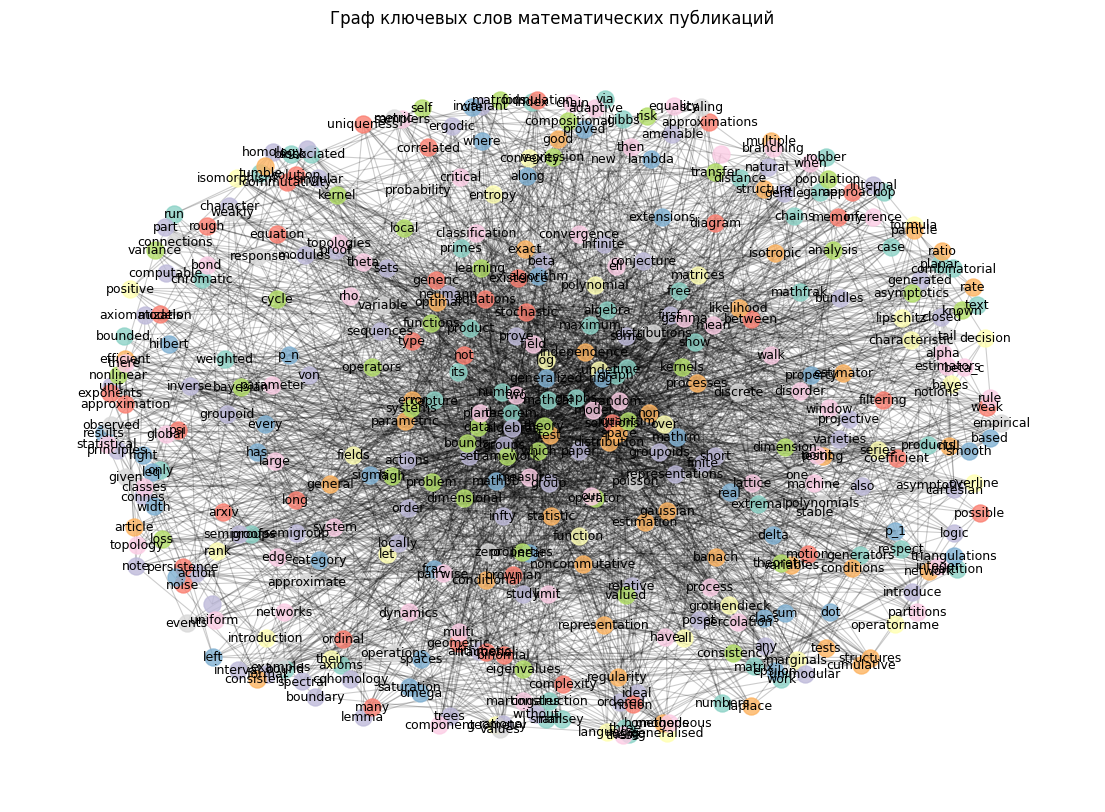

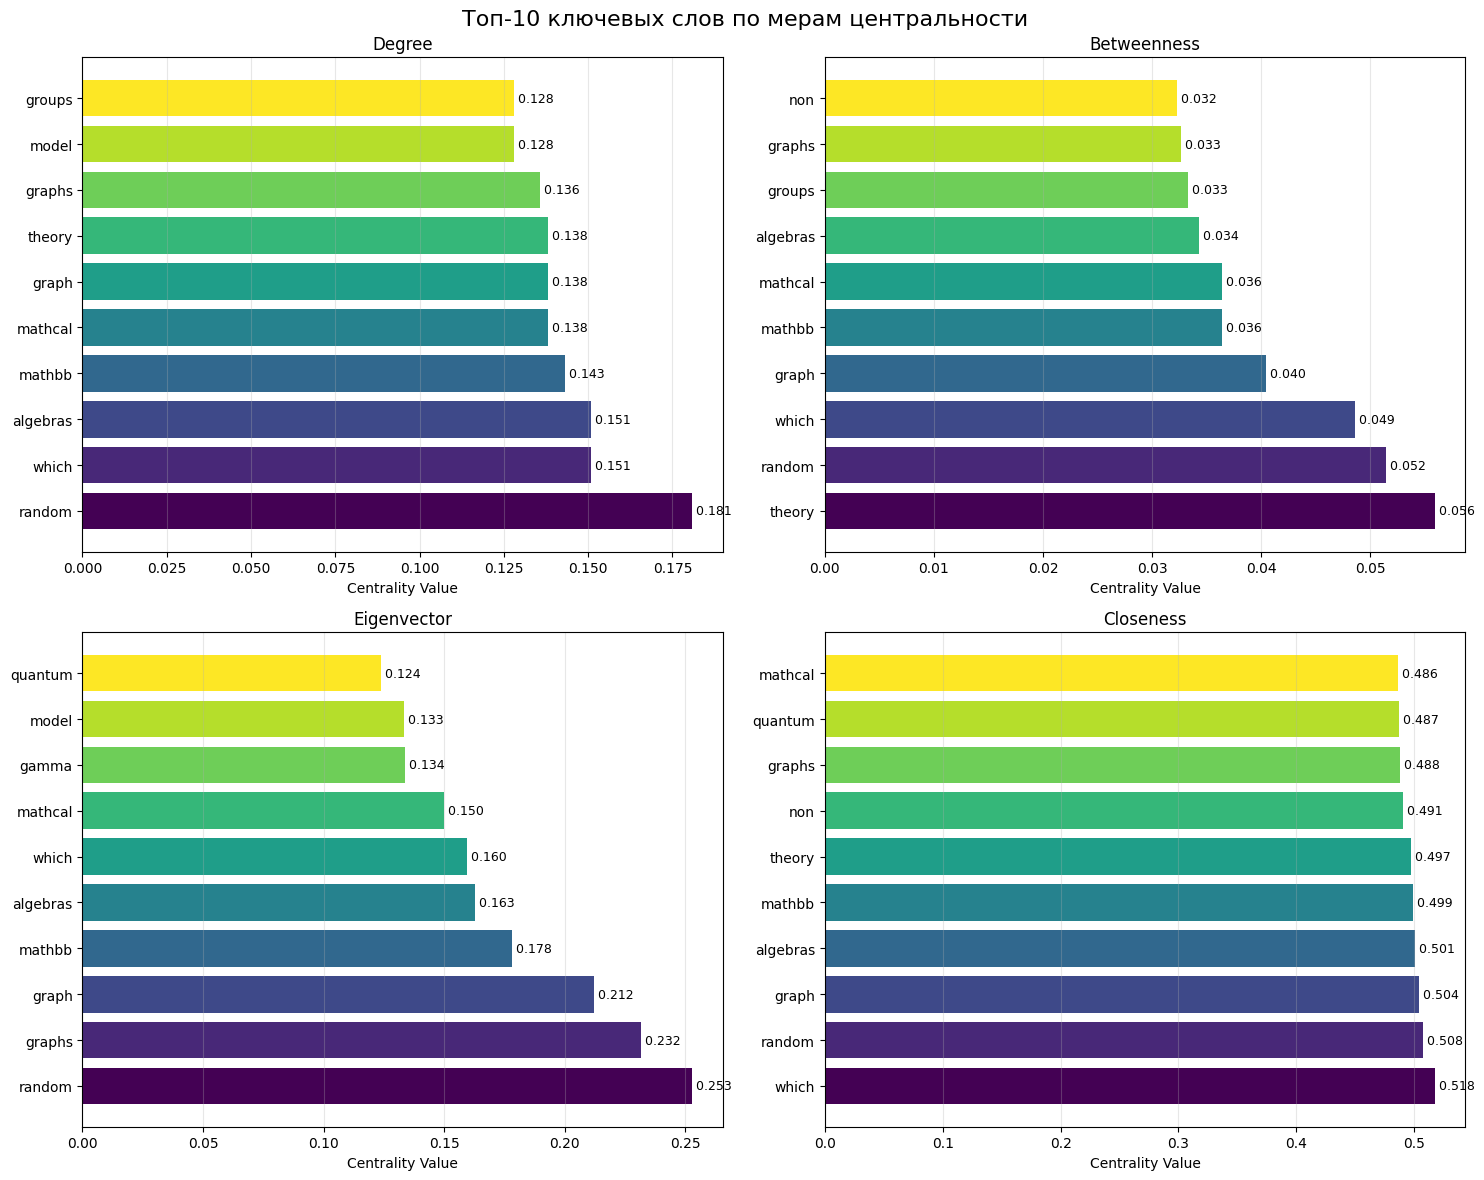

In [68]:
def visualize_results(G, communities):
    plt.figure(figsize=(14, 10))

    pos = nx.spring_layout(G, k=1, iterations=50, seed=42)

    for i, community in enumerate(communities):
        nx.draw_networkx_nodes(G, pos, nodelist=list(community),
                               node_color=[plt.cm.Set3(i % 12)],
                               node_size=150, alpha=0.8)

    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.8)

    important_nodes = [node for node, degree in dict(G.degree()).items() if degree > 4]
    labels = {node: node for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=9)

    plt.title("Граф ключевых слов математических публикаций")
    plt.axis('off')
    plt.show()


def plot_centrality_results(centrality_results, top_n=10):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (measure_name, data) in enumerate(centrality_results.items()):
        sorted_data = sorted(data.items(), key=lambda x: x[1], reverse=True)[:top_n]
        keywords = [item[0] for item in sorted_data]
        values = [item[1] for item in sorted_data]
        
        axes[idx].barh(keywords, values, color=plt.cm.viridis(np.linspace(0, 1, len(keywords))))
        axes[idx].set_title(f'{measure_name.replace("_", " ").title()}')
        axes[idx].set_xlabel('Centrality Value')
        axes[idx].grid(axis='x', alpha=0.3)
        
        for i, v in enumerate(values):
            axes[idx].text(v, i, f' {v:.3f}', va='center', fontsize=9)
    
    plt.suptitle(f'Топ-{top_n} ключевых слов по мерам центральности', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_results(keyword_graph, communities)
plot_centrality_results(centrality_results)

### Интерпретация результатов

In [69]:
print(f"\nКачество кластеризации: модулярность {modularity:.3f}")
print("> 0.7: отличная кластеризация")
print("0.3-0.7: хорошая кластеризация")
print("< 0.3: слабая кластеризация")

print(f"\nМодулярность {modularity:.3f} указывает на четкую структуру сообществ")

most_central = max(centrality_results['degree'].items(), key=lambda x: x[1])[0]
print(f"\nНаиболее центральное слово: '{most_central}'")

bridge_words = sorted(centrality_results['betweenness'].items(), key=lambda x: x[1], reverse=True)[:3]
print(f"Ключевые слова-мосты: {[word for word, _ in bridge_words]} - связывают разные области")

top_bridge_word = bridge_words[0][0]
bridge_neighbors = list(keyword_graph.neighbors(top_bridge_word))
print(f"Слово '{top_bridge_word}' связывает {len(bridge_neighbors)} различных понятий")
print(f"Наиболее важные связи: {bridge_neighbors[:5]}...")

cluster_sizes = [len(community) for community in communities]
print(f"\nРаспределение кластеров:")
print(f"Самый большой кластер: {max(cluster_sizes)} слов")
print(f"Самый маленький кластер: {min(cluster_sizes)} слов")
print(f"Средний размер: {sum(cluster_sizes) / len(cluster_sizes):.1f} слов")

avg_degree = sum(dict(keyword_graph.degree()).values()) / keyword_graph.number_of_nodes()
print(f"\nСредняя степень связности: {avg_degree:.1f} связей на слово")

print(f"\nТоп-3 ключевых слова по важности:")
for measure, values in centrality_results.items():
    top_3 = sorted(values.items(), key=lambda x: x[1], reverse=True)[:3]
    words = [f"'{word}'({value:.3f})" for word, value in top_3]
    print(f"{measure:12}: {', '.join(words)}")

print(f"\nМеждисциплинарный анализ:")
print(
    f"Слово 'theory' выступает мостом между {len([n for n in keyword_graph.neighbors('theory')])} различными понятиями")
print(f"Слово 'random' связано с {len([n for n in keyword_graph.neighbors('random')])} математическими концепциями")

print(f"\nОбнаружена четкая структура из {len(communities)} тематических кластеров")
print("с хорошими показателями модулярности и выраженными центральными понятиями")


Качество кластеризации: модулярность 0.373
> 0.7: отличная кластеризация
0.3-0.7: хорошая кластеризация
< 0.3: слабая кластеризация

Модулярность 0.373 указывает на четкую структуру сообществ

Наиболее центральное слово: 'random'
Ключевые слова-мосты: ['theory', 'random', 'which'] - связывают разные области
Слово 'theory' связывает 55 различных понятий
Наиболее важные связи: ['any', 'functions', 'paper', 'two', 'order']...

Распределение кластеров:
Самый большой кластер: 74 слов
Самый маленький кластер: 26 слов
Средний размер: 44.3 слов

Средняя степень связности: 14.5 связей на слово

Топ-3 ключевых слова по важности:
degree      : 'random'(0.181), 'which'(0.151), 'algebras'(0.151)
betweenness : 'theory'(0.056), 'random'(0.052), 'which'(0.049)
eigenvector : 'random'(0.253), 'graphs'(0.232), 'graph'(0.212)
closeness   : 'which'(0.518), 'random'(0.508), 'graph'(0.504)

Междисциплинарный анализ:
Слово 'theory' выступает мостом между 55 различными понятиями
Слово 'random' связано с 72 ма